## Prep DF

In [132]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [133]:
results_df = pd.read_csv("full_model_results.csv")

First, sort by cv_rmse

In [134]:
# best by CV RMSE within each outcome
best_by_rmse = (
    results_df
    .sort_values(["outcome", "cv_rmse", "r2"], ascending=[True, True, False])
    .groupby("outcome", as_index=False)
    .head(8)
)

best_by_rmse[["outcome", "model", "r2", "cv_rmse"]]

,outcome,model,r2,cv_rmse
51,cancer,raw_access,0.372482,2.384731
41,cancer,combined_only_pc,0.171439,2.468861
40,cancer,store_only_pc,0.133940,2.470346
46,cancer,controls_separate_pc,0.157381,2.507929
36,cancer,baseline,0.131084,2.556303
39,cancer,access_only_pc,0.131951,2.583162
50,cancer,rfei_plus_combined_quadratic,0.193229,2.674513
49,cancer,rfei_plus_combined_linear,0.172236,2.711230
33,diabetes,raw_access,0.707878,1.146671
18,diabetes,baseline,0.465824,1.462990


Sort by $R^2$

In [135]:
# best by adjusted R^2 within each outcome
best_by_r2 = (
    results_df
    .sort_values(["outcome", "r2", "cv_rmse"], ascending=[True, False, True])
    .groupby("outcome", as_index=False)
    .head(8)
)

best_by_r2[["outcome", "model", "r2", "cv_rmse"]]

,outcome,model,r2,cv_rmse
53,cancer,raw_all,0.605732,2.801748
51,cancer,raw_access,0.372482,2.384731
52,cancer,raw_store,0.327636,2.719932
50,cancer,rfei_plus_combined_quadratic,0.193229,2.674513
48,cancer,rfei_plus_separate_quadratic,0.183641,2.805844
49,cancer,rfei_plus_combined_linear,0.172236,2.711230
45,cancer,rfei_plus_store_quadratic,0.172038,2.732678
41,cancer,combined_only_pc,0.171439,2.468861
35,diabetes,raw_all,0.797597,1.508448
33,diabetes,raw_access,0.707878,1.146671


## Create $R^2$ Plot

In [136]:
plot_df = results_df.copy()

# get baseline r2 for each outcome
baseline_df = (
    plot_df.loc[plot_df["model"] == "baseline", ["outcome", "r2"]]
    .rename(columns={"r2": "baseline_r2"})
)

plot_df = plot_df.merge(baseline_df, on="outcome", how="left")
plot_df["delta_r2"] = plot_df["r2"] - plot_df["baseline_r2"]

# remove baseline itself; baseline is represented by y=0
plot_df = plot_df[plot_df["model"] != "baseline"].copy()

Fix labels

In [137]:
label_map = {
    "rfei_linear": "RFEI linear",
    "rfei_quadratic": "RFEI quad",
    "access_only_pc": "Access PCA",
    "store_only_pc": "Store PCA",
    "combined_only_pc": "Combined PCA",
    "rfei_plus_access_linear": "RFEI + Access",
    "rfei_plus_access_quadratic": "RFEI + Access quad",
    "rfei_plus_store_linear": "RFEI + Store",
    "rfei_plus_store_quadratic": "RFEI + Store quad",
    "controls_separate_pc": "Access + Store PCA",
    "rfei_plus_separate_linear": "RFEI + Sep PCA",
    "rfei_plus_separate_quadratic": "RFEI + Sep PCA quad",
    "rfei_plus_combined_linear": "RFEI + Comb PCA",
    "rfei_plus_combined_quadratic": "RFEI + Comb PCA quad",
    "raw_access": "Raw access",
    "raw_store": "Raw store",
    "raw_all": "Raw all"
}

plot_df["model_short"] = plot_df["model"].map(label_map).fillna(plot_df["model"])

Sort models

In [138]:
def model_family(model):
    m = model.lower()
    if "rfei" in m:
        return "RFEI"
    elif "raw" in m:
        return "Raw"
    elif "pc" in m or "combined" in m or "controls" in m:
        return "PCA / combined"
    else:
        return "Other"

plot_df["family"] = plot_df["model_short"].apply(model_family)

Aggregate and average over models for each category

In [139]:
avg_df = (
    plot_df.groupby(["model_short", "family"], as_index=False)
    .agg(
        mean_delta_r2=("delta_r2", "mean"),
        sd_delta_r2=("delta_r2", "std"),
        n=("delta_r2", "size")
    )
)

# sort models by average performance
model_order = avg_df.sort_values("mean_delta_r2", ascending=False)["model_short"].tolist()

Color code for poster, create plot

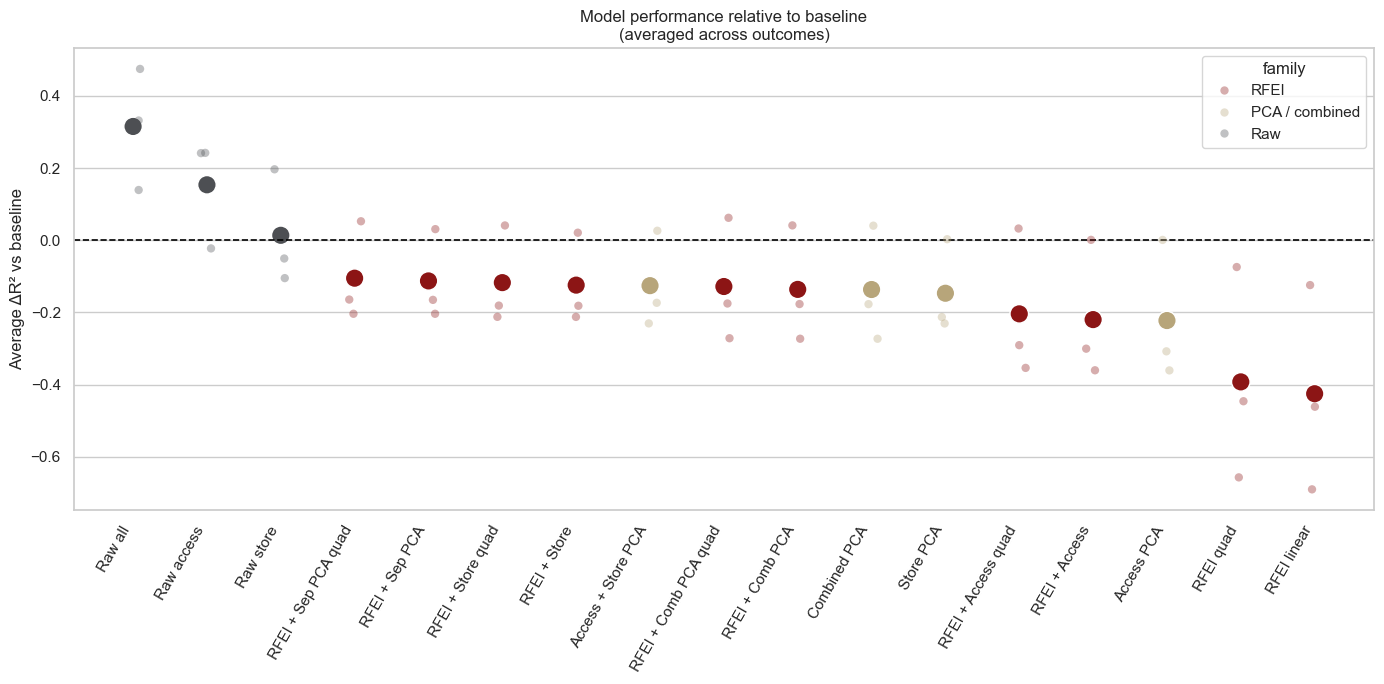

In [141]:
palette = {
    "RFEI": "#8C1515",
    "PCA / combined": "#B7A57A",
    "Raw": "#4D4F53",
    "Other": "#8C8C8C"
}

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# faint individual-outcome points
sns.stripplot(
    data=plot_df,
    x="model_short",
    y="delta_r2",
    order=model_order,
    hue="family",
    palette=palette,
    dodge=False,
    alpha=0.35,
    size=6
)

# larger average points
sns.scatterplot(
    data=avg_df,
    x="model_short",
    y="mean_delta_r2",
    hue="family",
    palette=palette,
    s=180,
    legend=False
)

# dotted baseline line
plt.axhline(0, linestyle="--", color="black", linewidth=1.2)

plt.xlabel("")
plt.ylabel("Average ΔR² vs baseline")
plt.title("Model performance relative to baseline\n(averaged across outcomes)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

## Create RMSE Plot

In [142]:
plot_df = results_df.copy()

# get baseline CV RMSE for each outcome
baseline_df = (
    plot_df.loc[plot_df["model"] == "baseline", ["outcome", "cv_rmse"]]
    .rename(columns={"cv_rmse": "baseline_cv_rmse"})
)

plot_df = plot_df.merge(baseline_df, on="outcome", how="left")

# negate percent change relative to baseline so HIGHER = BETTER
plot_df["neg_pct_delta_rmse"] = -(
    (plot_df["cv_rmse"] - plot_df["baseline_cv_rmse"]) / plot_df["baseline_cv_rmse"]
) * 100

# remove baseline itself; baseline is represented by y=0
plot_df = plot_df[plot_df["model"] != "baseline"].copy()

Fix labels

In [143]:
label_map = {
    "rfei_linear": "RFEI linear",
    "rfei_quadratic": "RFEI quad",
    "access_only_pc": "Access PCA",
    "store_only_pc": "Store PCA",
    "combined_only_pc": "Combined PCA",
    "rfei_plus_access_linear": "RFEI + Access",
    "rfei_plus_access_quadratic": "RFEI + Access quad",
    "rfei_plus_store_linear": "RFEI + Store",
    "rfei_plus_store_quadratic": "RFEI + Store quad",
    "controls_separate_pc": "Access + Store PCA",
    "rfei_plus_separate_linear": "RFEI + Sep PCA",
    "rfei_plus_separate_quadratic": "RFEI + Sep PCA quad",
    "rfei_plus_combined_linear": "RFEI + Comb PCA",
    "rfei_plus_combined_quadratic": "RFEI + Comb PCA quad",
    "raw_access": "Raw access",
    "raw_store": "Raw store",
    "raw_all": "Raw all"
}
plot_df["model_short"] = plot_df["model"].map(label_map).fillna(plot_df["model"])

Aggregate and average; make sure that higher (visually) corresponds to better

In [144]:
plot_df["family"] = plot_df["model_short"].apply(model_family)

In [145]:
avg_df = (
    plot_df.groupby(["model_short", "family"], as_index=False)
    .agg(
        mean_neg_pct_delta_rmse=("neg_pct_delta_rmse", "mean"),
        sd_neg_pct_delta_rmse=("neg_pct_delta_rmse", "std"),
        n=("neg_pct_delta_rmse", "size")
    )
)

# higher is now better
model_order = avg_df.sort_values("mean_neg_pct_delta_rmse", ascending=False)["model_short"].tolist()

Color code and create

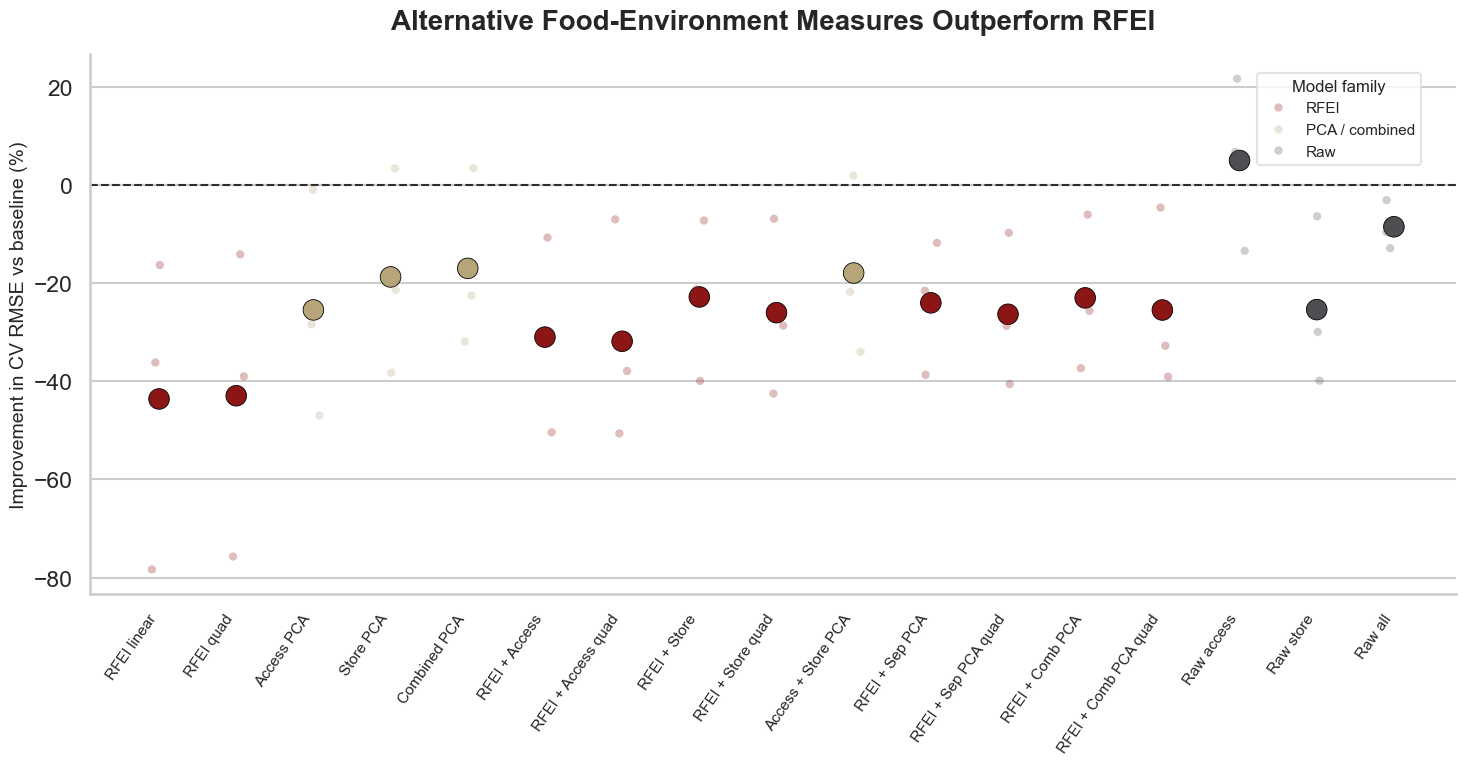

In [148]:
palette = {
    "RFEI": "#8C1515",
    "PCA / combined": "#B7A57A",
    "Raw": "#4D4F53",
    "Other": "#8C8C8C"
}

sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(15, 8))

# faint individual outcome points
sns.stripplot(
    data=plot_df,
    x="model_short",
    y="neg_pct_delta_rmse",
    hue="family",
    palette=palette,
    dodge=False,
    alpha=0.28,
    size=6,
    ax=ax
)

# large average points
sns.scatterplot(
    data=avg_df,
    x="model_short",
    y="mean_neg_pct_delta_rmse",
    hue="family",
    palette=palette,
    s=220,
    edgecolor="black",
    linewidth=0.6,
    legend=False,
    ax=ax
)

# baseline reference line
ax.axhline(0, linestyle="--", color="#2E2D29", linewidth=1.5)

# titles
ax.set_title(
    "Alternative Food-Environment Measures Outperform RFEI",
    fontsize=20,
    weight="bold",
    pad=18
)

# labels
ax.set_xlabel("")
ax.set_ylabel("Improvement in CV RMSE vs baseline (%)", fontsize=14)

# clean ticks
ax.tick_params(axis="x", rotation=55)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
    label.set_fontsize(11)

# cleaner legend
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))

ax.legend(
    unique.values(),
    unique.keys(),
    title="Model family",
    frameon=True,
    facecolor="white",
    edgecolor="#DDDDDD",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    fontsize=11,
    title_fontsize=12
)

# lighten spines
sns.despine(ax=ax, left=False, bottom=False)

plt.tight_layout()
plt.show()

## Plot store regression with/without SNAP

In [73]:
snap = pd.read_csv("store_snap.csv")

In [74]:
only_snap = pd.read_csv("only_snap.csv")

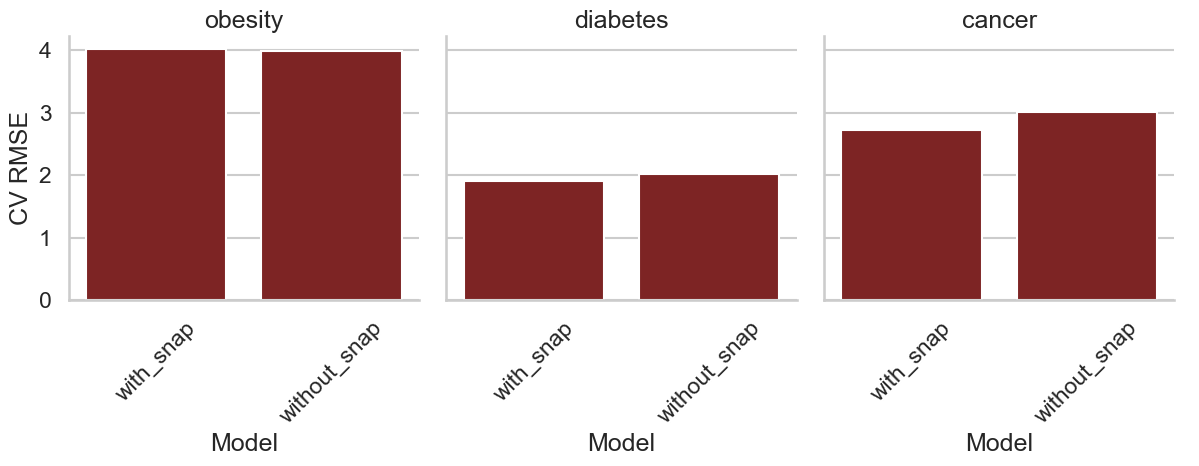

In [83]:
sns.set_theme(style="whitegrid", context="talk")
g1 = sns.catplot(
    data=snap,
    kind="bar",
    x="model",
    y="cv_rmse",
    col="outcome",
    sharey=True,
    height=5,
    aspect=0.8,
    color="#8C1515"
)

g1.set_titles("{col_name}")
g1.set_axis_labels("Model", "CV RMSE")

for ax in g1.axes.flat:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

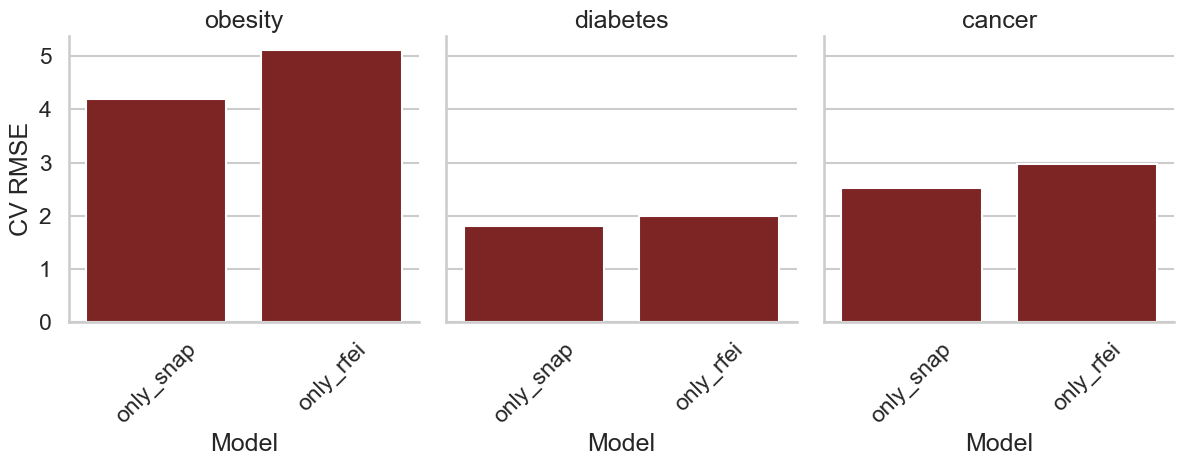

In [85]:
# Plot 2
sns.set_theme(style="whitegrid", context="talk")
g2 = sns.catplot(
    data=only_snap,
    kind="bar",
    x="model",
    y="cv_rmse",
    col="outcome",
    sharey=True,
    height=5,
    aspect=0.8,
    color="#8C1515"
)

g2.set_titles("{col_name}")
g2.set_axis_labels("Model", "CV RMSE")

for ax in g2.axes.flat:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()